# Phase-length `q` tradeoff for Private SpiderBoost

Sweep over phase length `q` at fixed privacy budget `epsilon`, using the `dimma` library. Adapted from `private_spider_boost_criteo/notebooks/phase_length_q_tradeoff.ipynb`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

HERE = Path('.').resolve()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import jax
import jax.numpy as jnp
import numpy as np
from sklearn.metrics import roc_auc_score

import dimma
from dimma import TrainConfig, compute_noise_scales
from dimma.datasets import load_criteo

import model
import visualization as viz

## 2. Data and sweep configuration

In [2]:
FIGS_DIR = HERE / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

data = load_criteo(features='integer', test_fraction=0.2, seed=0, device='cpu')
x_train, y_train = data.x_train, data.y_train
x_test, y_test = data.x_test, data.y_test
n_train, d = x_train.shape

Q_VALUES = [5, 10, 30, 100, 200]
HIDDEN_DIMS = (64, 32)

BASE = dict(
    epsilon=10.0,
    delta=1.0 / (1.1 * n_train),
    L0=3.0,
    L1=5.0,
    T=1000,
    b1=8192,
    b2=512,
    eta=0.01,
    seed=0,
)
BASE

{'epsilon': 10.0,
 'delta': 1.1363636363636362e-06,
 'L0': 3.0,
 'L1': 5.0,
 'T': 1000,
 'b1': 8192,
 'b2': 512,
 'eta': 0.01,
 'seed': 0}

## 3. AUC helper

In [3]:
@jax.jit
def predict_logits(params, x):
    return model.forward(params, x)

def evaluate_auc(params, x, y):
    logits = predict_logits(params, x)
    return float(roc_auc_score(np.asarray(y), np.asarray(logits)))

## 4. Sweep

In [4]:
auc_random_list = []
auc_final_list = []
for q in Q_VALUES:
    cfg = TrainConfig(q=q, **BASE)
    noise_scales = compute_noise_scales(
        L0=cfg.L0, L1=cfg.L1, epsilon=cfg.epsilon, delta=cfg.delta,
        T=cfg.T, q=cfg.q, n=n_train, b1=cfg.b1, b2=cfg.b2,
    )
    key = jax.random.PRNGKey(cfg.seed)
    init_params = model.init_params(key, input_dim=d, hidden_dims=HIDDEN_DIMS)
    print(f'--- q = {q} ---')
    res = dimma.train(
        x_train, y_train,
        per_sample_loss_fn=model.per_sample_bce_loss,
        init_params=init_params,
        config=cfg, noise_scales=noise_scales,
        sampler='poisson',
    )
    a_rand = evaluate_auc(res.params_random, x_test, y_test)
    a_fin = evaluate_auc(res.params_final, x_test, y_test)
    auc_random_list.append(a_rand)
    auc_final_list.append(a_fin)
    print(f'   AUC(w_bar)={a_rand:.4f}   AUC(w_T)={a_fin:.4f}   ({sum(res.history.wall_time_s):.1f}s)')

--- q = 5 ---
   AUC(w_bar)=0.6604   AUC(w_T)=0.6771   (9.1s)
--- q = 10 ---
   AUC(w_bar)=0.6604   AUC(w_T)=0.6771   (7.5s)
--- q = 30 ---
   AUC(w_bar)=0.6608   AUC(w_T)=0.6774   (7.2s)
--- q = 100 ---
   AUC(w_bar)=0.6609   AUC(w_T)=0.6763   (7.0s)
--- q = 200 ---
   AUC(w_bar)=0.6648   AUC(w_T)=0.6765   (6.9s)


## 5. Plot

{'q': [5, 10, 30, 100, 200], 'auc_random': [0.6603899332744462, 0.6603844915144088, 0.6607563567661913, 0.6608593241368517, 0.6647539329083907], 'auc_final': [0.6771080138968467, 0.6770768025581445, 0.6773718606760886, 0.6763435984052713, 0.6765321947150073]}


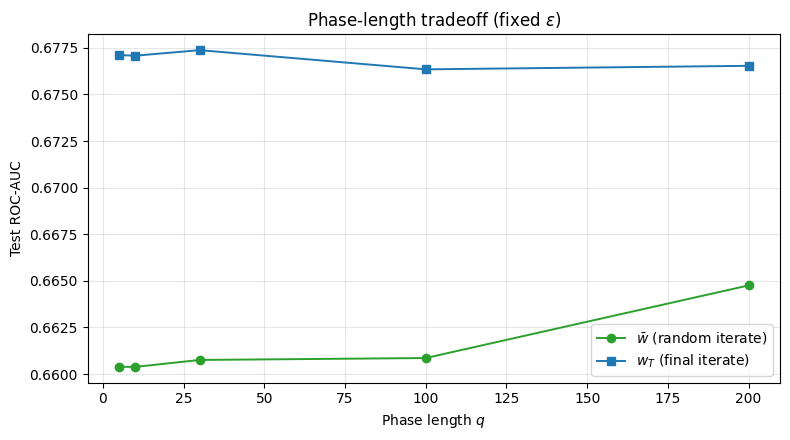

In [5]:
_ = viz.plot_q_sweep(Q_VALUES, auc_random_list, auc_final_list,
                      FIGS_DIR / 'phase_length_q_tradeoff.png')
print({'q': Q_VALUES, 'auc_random': auc_random_list, 'auc_final': auc_final_list})